# SECTION 1: DECLARE THE MODULES

In [5]:
import os
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')




# SECTION 2: Data import and preprocess
#Run this but dont worry if it does not make any sense Jump to SECTION 3 that is related to your HD task.

In [6]:
!pip install wget
import wget

link_to_data = 'https://raw.githubusercontent.com/SIT719/2020-S2/master/data/Week_5_NSL-KDD-Dataset/training_attack_types.txt?raw=true'
DataSet = wget.download(link_to_data)

In [7]:
DataSet

'training_attack_types (1).txt'

In [8]:
header_names = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type', 'success_pred']


# Differentiating between nominal, binary, and numeric features

# root_shell is marked as a continuous feature in the kddcup.names
# file, but it is supposed to be a binary feature according to the
# dataset documentation

# training_attack_types.txt maps each of the 22 different attacks to 1 of 4 categories
# file obtained from http://kdd.ics.uci.edu/databases/kddcup99/training_attack_types

col_names = np.array(header_names)

nominal_idx = [1, 2, 3]
binary_idx = [6, 11, 13, 14, 20, 21]
numeric_idx = list(set(range(41)).difference(nominal_idx).difference(binary_idx))

nominal_cols = col_names[nominal_idx].tolist()
binary_cols = col_names[binary_idx].tolist()
numeric_cols = col_names[numeric_idx].tolist()

In [9]:
# training_attack_types.txt maps each of the 22 different attacks to 1 of 4 categories
# file obtained from http://kdd.ics.uci.edu/databases/kddcup99/training_attack_types

category = defaultdict(list)
category['benign'].append('normal')

with open(DataSet, 'r') as f:
    for line in f.readlines():
        attack, cat = line.strip().split(' ')
        category[cat].append(attack)

attack_mapping = dict((v,k) for k in category for v in category[k])

In [10]:
attack_mapping

{'normal': 'benign',
 'apache2': 'dos',
 'back': 'dos',
 'mailbomb': 'dos',
 'processtable': 'dos',
 'snmpgetattack': 'dos',
 'teardrop': 'dos',
 'smurf': 'dos',
 'land': 'dos',
 'neptune': 'dos',
 'pod': 'dos',
 'udpstorm': 'dos',
 'ps': 'u2r',
 'buffer_overflow': 'u2r',
 'perl': 'u2r',
 'rootkit': 'u2r',
 'loadmodule': 'u2r',
 'xterm': 'u2r',
 'sqlattack': 'u2r',
 'httptunnel': 'u2r',
 'ftp_write': 'r2l',
 'guess_passwd': 'r2l',
 'snmpguess': 'r2l',
 'imap': 'r2l',
 'spy': 'r2l',
 'warezclient': 'r2l',
 'warezmaster': 'r2l',
 'multihop': 'r2l',
 'phf': 'r2l',
 'named': 'r2l',
 'sendmail': 'r2l',
 'xlock': 'r2l',
 'xsnoop': 'r2l',
 'worm': 'probe',
 'nmap': 'probe',
 'ipsweep': 'probe',
 'portsweep': 'probe',
 'satan': 'probe',
 'mscan': 'probe',
 'saint': 'probe'}

In [11]:
#Processing Training Data

train_file='https://raw.githubusercontent.com/SIT719/2020-S2/master/data/Week_5_NSL-KDD-Dataset/KDDTrain%2B.txt'



train_df = pd.read_csv(train_file, names=header_names)

train_df['attack_category'] = train_df['attack_type'] \
                                .map(lambda x: attack_mapping[x])

train_df.drop(['success_pred'], axis=1, inplace=True)






In [12]:
#Processing test Data
test_file='https://raw.githubusercontent.com/SIT719/2020-S2/master/data/Week_5_NSL-KDD-Dataset/KDDTest%2B.txt'

test_df = pd.read_csv(test_file, names=header_names)
test_df['attack_category'] = test_df['attack_type'] \
                                .map(lambda x: attack_mapping[x])
test_df.drop(['success_pred'], axis=1, inplace=True)

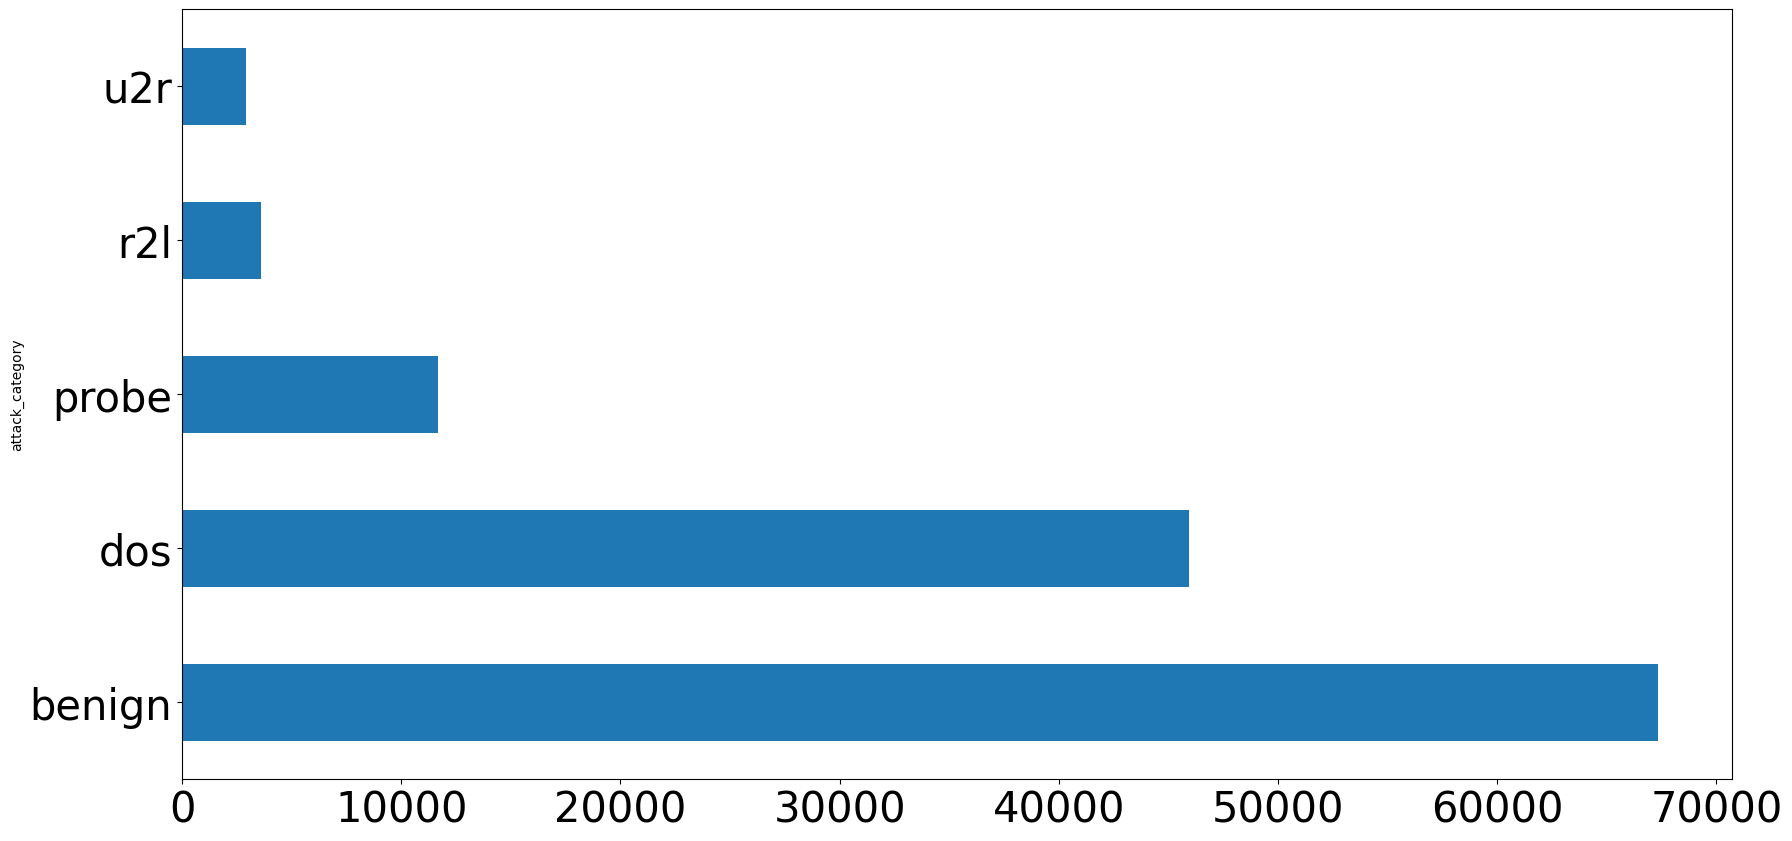

In [13]:
train_attack_types = train_df['attack_type'].value_counts()
train_attack_cats = train_df['attack_category'].value_counts()

test_attack_types = test_df['attack_type'].value_counts()
test_attack_cats = test_df['attack_category'].value_counts()

train_attack_types.plot(kind='barh', figsize=(20,10), fontsize=20)

train_attack_cats.plot(kind='barh', figsize=(20,10), fontsize=30)

train_df[binary_cols].describe().transpose()
train_df.groupby(['su_attempted']).size()
train_df['su_attempted'].replace(2, 0, inplace=True)
test_df['su_attempted'].replace(2, 0, inplace=True)
train_df.groupby(['su_attempted']).size()
train_df.groupby(['num_outbound_cmds']).size()

#Now, that's not a very useful feature - let's drop it from the dataset

train_df.drop('num_outbound_cmds', axis = 1, inplace=True)
test_df.drop('num_outbound_cmds', axis = 1, inplace=True)
numeric_cols.remove('num_outbound_cmds')



#Data Preparation

train_Y = train_df['attack_category']
train_x_raw = train_df.drop(['attack_category','attack_type'], axis=1)
test_Y = test_df['attack_category']
test_x_raw = test_df.drop(['attack_category','attack_type'], axis=1)


combined_df_raw = pd.concat([train_x_raw, test_x_raw])
combined_df = pd.get_dummies(combined_df_raw, columns=nominal_cols, drop_first=True)

train_x = combined_df[:len(train_x_raw)]
test_x = combined_df[len(train_x_raw):]

# Store dummy variable feature names
dummy_variables = list(set(train_x)-set(combined_df_raw))

#execute the commands in console
train_x.describe()
train_x['duration'].describe()
# Experimenting with StandardScaler on the single 'duration' feature
from sklearn.preprocessing import StandardScaler

durations = train_x['duration'].values.reshape(-1, 1)
standard_scaler = StandardScaler().fit(durations)
scaled_durations = standard_scaler.transform(durations)
pd.Series(scaled_durations.flatten()).describe()

# Experimenting with MinMaxScaler on the single 'duration' feature
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler().fit(durations)
min_max_scaled_durations = min_max_scaler.transform(durations)
pd.Series(min_max_scaled_durations.flatten()).describe()

# Experimenting with RobustScaler on the single 'duration' feature
from sklearn.preprocessing import RobustScaler

min_max_scaler = RobustScaler().fit(durations)
robust_scaled_durations = min_max_scaler.transform(durations)
pd.Series(robust_scaled_durations.flatten()).describe()

# Experimenting with MaxAbsScaler on the single 'duration' feature
from sklearn.preprocessing import MaxAbsScaler

max_Abs_scaler = MaxAbsScaler().fit(durations)
robust_scaled_durations = max_Abs_scaler.transform(durations)
pd.Series(robust_scaled_durations.flatten()).describe()

# Let's proceed with StandardScaler- Apply to all the numeric columns

standard_scaler = StandardScaler().fit(train_x[numeric_cols])

train_x[numeric_cols] = \
    standard_scaler.transform(train_x[numeric_cols])

test_x[numeric_cols] = \
    standard_scaler.transform(test_x[numeric_cols])

train_x.describe()



train_Y_bin = train_Y.apply(lambda x: 0 if x is 'benign' else 1)
test_Y_bin = test_Y.apply(lambda x: 0 if x is 'benign' else 1)


# SECTION 3: Multi class classification
#This is the section where you have to add other algorithms, tune algorithms and visualize to compare and analyze algorithms

In [24]:
# 5-class classification version

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

# Class labels mapping (you can adjust this based on how your classes are labeled)
class_labels = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

# Initialize the KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Train the classifier on the training data
knn_classifier.fit(train_x, train_Y)

# Predict the labels for the test data
pred_y_knn = knn_classifier.predict(test_x)

# Calculate the confusion matrix
conf_matrix_knn = confusion_matrix(test_Y, pred_y_knn)

# Calculate performance metrics
precision_knn = precision_score(test_Y, pred_y_knn, average=None) * 100  # Precision for each class
recall_knn = recall_score(test_Y, pred_y_knn, average=None) * 100        # Recall for each class
f1_knn = f1_score(test_Y, pred_y_knn, average=None) * 100                # F1-Score for each class

# Calculate the False Positive Rate (FPR) for each class
FP_knn = conf_matrix_knn.sum(axis=0) - np.diag(conf_matrix_knn)  # False Positives for each class
TN_knn = conf_matrix_knn.sum() - (FP_knn + np.diag(conf_matrix_knn) + conf_matrix_knn.sum(axis=1) - np.diag(conf_matrix_knn))  # True Negatives for each class
FPR_knn = (FP_knn / (FP_knn + TN_knn)) * 100  # FPR for each class

# Create a pandas DataFrame to display the results in a table
results_table = pd.DataFrame({
    'Class': class_labels,
    'Precision (%)': precision_knn,
    'Recall (%)': recall_knn,
    'F1-Score (%)': f1_knn,
    'False Positive Rate (FPR) (%)': FPR_knn
})

# Display the confusion matrix and the results table
print("K-Nearest Neighbors (KNN) Confusion Matrix:\n", conf_matrix_knn)
print("\nPerformance Metrics Table:\n", results_table)




K-Nearest Neighbors (KNN) Confusion Matrix:
 [[9444   54  207    5    1]
 [1630 5925   81    0    0]
 [ 614  180 1629    0    0]
 [2362    2   40  170    0]
 [ 170    0   17    4    9]]

Performance Metrics Table:
     Class  Precision (%)  Recall (%)  F1-Score (%)  \
0  Normal      66.413502   97.250541     78.926915   
1     DoS      96.169453   77.592981     85.888237   
2   Probe      82.522796   67.230706     74.095975   
3     R2L      94.972067    6.604507     12.350163   
4     U2R      90.000000    4.500000      8.571429   

   False Positive Rate (FPR) (%)  
0                      37.216551  
1                       1.583043  
2                       1.714627  
3                       0.045068  
4                       0.004475  


In [25]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

# Class labels mapping (you can adjust this based on how your classes are labeled)
class_labels = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

# Initialize the SVM classifier
svm_classifier = SVC(kernel='linear', random_state=17)  # You can choose different kernels if needed

# Train the classifier on the training data
svm_classifier.fit(train_x, train_Y)

# Predict the labels for the test data
pred_y_svm = svm_classifier.predict(test_x)

# Calculate the confusion matrix
conf_matrix_svm = confusion_matrix(test_Y, pred_y_svm)

# Calculate performance metrics
precision_svm = precision_score(test_Y, pred_y_svm, average=None) * 100  # Precision for each class
recall_svm = recall_score(test_Y, pred_y_svm, average=None) * 100        # Recall for each class
f1_svm = f1_score(test_Y, pred_y_svm, average=None) * 100                # F1-Score for each class

# Calculate the False Positive Rate (FPR) for each class
FP_svm = conf_matrix_svm.sum(axis=0) - np.diag(conf_matrix_svm)  # False Positives for each class
TN_svm = conf_matrix_svm.sum() - (FP_svm + np.diag(conf_matrix_svm) + conf_matrix_svm.sum(axis=1) - np.diag(conf_matrix_svm))  # True Negatives for each class
FPR_svm = (FP_svm / (FP_svm + TN_svm)) * 100  # FPR for each class

# Create a pandas DataFrame to display the results in a table
results_table_svm = pd.DataFrame({
    'Class': class_labels,
    'Precision (%)': precision_svm,
    'Recall (%)': recall_svm,
    'F1-Score (%)': f1_svm,
    'False Positive Rate (FPR) (%)': FPR_svm
})

# Display the confusion matrix and the results table
print("Support Vector Machine (SVM) Confusion Matrix:\n", conf_matrix_svm)
print("\nPerformance Metrics Table:\n", results_table_svm)


Support Vector Machine (SVM) Confusion Matrix:
 [[9040  225  437    4    5]
 [1445 6179   12    0    0]
 [ 720  115 1588    0    0]
 [2291    1    2  275    5]
 [ 180    1    0    3   16]]

Performance Metrics Table:
     Class  Precision (%)  Recall (%)  F1-Score (%)  \
0  Normal      66.101199   93.090310     77.307906   
1     DoS      94.755406   80.919329     87.292505   
2   Probe      77.881314   65.538589     71.178844   
3     R2L      97.517730   10.683761     19.257703   
4     U2R      61.538462    8.000000     14.159292   

   False Positive Rate (FPR) (%)  
0                      36.125614  
1                       2.294070  
2                       2.241439  
3                       0.035053  
4                       0.044755  


In [26]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

# Class labels mapping (you can adjust this based on how your classes are labeled)
class_labels = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

# Initialize the Logistic Regression classifier
logistic_regressor = LogisticRegression(random_state=17, max_iter=1000)  # Adjust max_iter if needed

# Train the classifier on the training data
logistic_regressor.fit(train_x, train_Y)

# Predict the labels for the test data
pred_y_logistic = logistic_regressor.predict(test_x)

# Calculate the confusion matrix
conf_matrix_logistic = confusion_matrix(test_Y, pred_y_logistic)

# Calculate performance metrics
precision_logistic = precision_score(test_Y, pred_y_logistic, average=None) * 100  # Precision for each class
recall_logistic = recall_score(test_Y, pred_y_logistic, average=None) * 100        # Recall for each class
f1_logistic = f1_score(test_Y, pred_y_logistic, average=None) * 100                # F1-Score for each class

# Calculate the False Positive Rate (FPR) for each class
FP_logistic = conf_matrix_logistic.sum(axis=0) - np.diag(conf_matrix_logistic)  # False Positives for each class
TN_logistic = conf_matrix_logistic.sum() - (FP_logistic + np.diag(conf_matrix_logistic) + conf_matrix_logistic.sum(axis=1) - np.diag(conf_matrix_logistic))  # True Negatives for each class
FPR_logistic = (FP_logistic / (FP_logistic + TN_logistic)) * 100  # FPR for each class

# Create a pandas DataFrame to display the results in a table
results_table_logistic = pd.DataFrame({
    'Class': class_labels,
    'Precision (%)': precision_logistic,
    'Recall (%)': recall_logistic,
    'F1-Score (%)': f1_logistic,
    'False Positive Rate (FPR) (%)': FPR_logistic
})

# Display the confusion matrix and the results table
print("Logistic Regression Confusion Matrix:\n", conf_matrix_logistic)
print("\nPerformance Metrics Table:\n", results_table_logistic)


Logistic Regression Confusion Matrix:
 [[9007  300  401    1    2]
 [1679 5947   10    0    0]
 [ 539  106 1754   24    0]
 [2522    3    1   48    0]
 [ 182    4    0    3   11]]

Performance Metrics Table:
     Class  Precision (%)  Recall (%)  F1-Score (%)  \
0  Normal      64.663651   92.750489     76.201354   
1     DoS      93.506289   77.881090     84.981423   
2   Probe      80.978763   72.389600     76.443670   
3     R2L      63.157895    1.864802      3.622642   
4     U2R      84.615385    5.500000     10.328638   

   False Positive Rate (FPR) (%)  
0                      38.354243  
1                       2.770325  
2                       2.047612  
3                       0.140210  
4                       0.008951  


In [27]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

# Class labels mapping (adjust this based on how your classes are labeled)
class_labels = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

# Initialize the Naive Bayes classifier
naive_bayes_classifier = GaussianNB()

# Train the classifier on the training data
naive_bayes_classifier.fit(train_x, train_Y)

# Predict the labels for the test data
pred_y_nb = naive_bayes_classifier.predict(test_x)

# Calculate the confusion matrix
conf_matrix_nb = confusion_matrix(test_Y, pred_y_nb)

# Calculate performance metrics
precision_nb = precision_score(test_Y, pred_y_nb, average=None) * 100  # Precision for each class
recall_nb = recall_score(test_Y, pred_y_nb, average=None) * 100        # Recall for each class
f1_nb = f1_score(test_Y, pred_y_nb, average=None) * 100                # F1-Score for each class

# Calculate the False Positive Rate (FPR) for each class
FP_nb = conf_matrix_nb.sum(axis=0) - np.diag(conf_matrix_nb)  # False Positives for each class
TN_nb = conf_matrix_nb.sum() - (FP_nb + np.diag(conf_matrix_nb) + conf_matrix_nb.sum(axis=1) - np.diag(conf_matrix_nb))  # True Negatives for each class
FPR_nb = (FP_nb / (FP_nb + TN_nb)) * 100  # FPR for each class

# Create a pandas DataFrame to display the results in a table
results_table_nb = pd.DataFrame({
    'Class': class_labels,
    'Precision (%)': precision_nb,
    'Recall (%)': recall_nb,
    'F1-Score (%)': f1_nb,
    'False Positive Rate (FPR) (%)': FPR_nb
})

# Display the confusion matrix and the results table
print("Naive Bayes Confusion Matrix:\n", conf_matrix_nb)
print("\nPerformance Metrics Table:\n", results_table_nb)


Naive Bayes Confusion Matrix:
 [[6756   62   10 2599  284]
 [3400 3162    4 1041   29]
 [1382  345  237  323  136]
 [1113    3    6  933  519]
 [ 115    0    0   22   63]]

Performance Metrics Table:
     Class  Precision (%)  Recall (%)  F1-Score (%)  \
0  Normal      52.921824   69.570590     60.114784   
1     DoS      88.521837   41.409115     56.423983   
2   Probe      92.217899    9.781263     17.686567   
3     R2L      18.971126   36.247086     24.906567   
4     U2R       6.110572   31.500000     10.235581   

   False Positive Rate (FPR) (%)  
0                      46.832385  
1                       2.750201  
2                       0.099399  
3                      19.954932  
4                       4.332259  
